In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/ecommerce_validated.csv")

In [2]:
df.head()

,order_id,customer_id,customer_name,city,product_category,price,quantity,payment_method,order_date,delivery_days,rating
0,ORD100000,CUS5064,Stephanie Sellers,East Deborah,Sports,754.66,2,Net Banking,2026-01-22,3,4.2
1,ORD100001,CUS2698,Michael Serrano,Longtown,Clothing,4555.67,4,Debit Card,2024-04-22,7,2.7
2,ORD100002,CUS3200,Brenda Jefferson,Lake Donald,Clothing,1279.42,2,Debit Card,2024-05-11,6,4.8
3,ORD100003,CUS3731,Michelle Singleton,New Patriciamouth,Clothing,3380.20,4,UPI,2025-06-13,1,4.7
4,ORD100004,CUS3085,Jack Johnson,Erictown,Home,3795.27,2,Net Banking,2025-05-05,4,3.2


In [3]:
df["revenue"] = df["price"] * df["quantity"]
df.head()

,order_id,customer_id,customer_name,city,product_category,price,quantity,payment_method,order_date,delivery_days,rating,revenue
0,ORD100000,CUS5064,Stephanie Sellers,East Deborah,Sports,754.66,2,Net Banking,2026-01-22,3,4.2,1509.32
1,ORD100001,CUS2698,Michael Serrano,Longtown,Clothing,4555.67,4,Debit Card,2024-04-22,7,2.7,18222.68
2,ORD100002,CUS3200,Brenda Jefferson,Lake Donald,Clothing,1279.42,2,Debit Card,2024-05-11,6,4.8,2558.84
3,ORD100003,CUS3731,Michelle Singleton,New Patriciamouth,Clothing,3380.20,4,UPI,2025-06-13,1,4.7,13520.80
4,ORD100004,CUS3085,Jack Johnson,Erictown,Home,3795.27,2,Net Banking,2025-05-05,4,3.2,7590.54


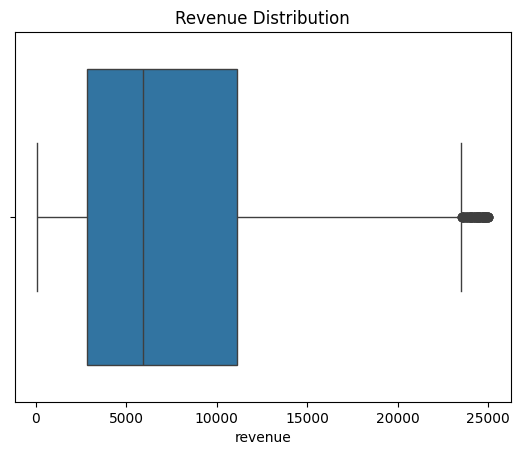

In [4]:
# Visualize Revenue Distribution
sns.boxplot(x=df["revenue"])
plt.title("Revenue Distribution")
plt.show()

In [5]:
# Detect Outliers Using IQR
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

In [6]:
# Calculate Outlier Boundaries
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [7]:
#Identify Anomalous Transactions
anomalies = df[(df["revenue"] > upper_limit) | (df["revenue"] < lower_limit)]

print("Number of suspicious transactions:", anomalies.shape[0])

# View Suspicious Orders
anomalies.head()

Number of suspicious transactions: 90


,order_id,customer_id,customer_name,city,product_category,price,quantity,payment_method,order_date,delivery_days,rating,revenue
231,ORD100231,CUS1390,Donald Rollins,North Angelaside,Books,4710.10,5,Net Banking,2025-09-16,4,3.0,23550.50
292,ORD100292,CUS1516,Michelle Parker,New Lauren,Home,4943.42,5,Cash on Delivery,2024-07-21,1,4.0,24717.10
494,ORD100494,CUS3941,Anna Hopkins,Mooreland,Electronics,4964.45,5,Net Banking,2025-04-21,3,3.6,24822.25
675,ORD100675,CUS2582,Courtney Moyer,East Christineborough,Electronics,4970.75,5,UPI,2025-11-20,4,2.8,24853.75
722,ORD100722,CUS7096,Deborah Love,North Jeffreyview,Books,4923.88,5,Net Banking,2025-07-21,2,2.8,24619.40


In [8]:
anomalies.to_csv("../data/processed/anomalous_transactions.csv", index=False)